# Individual Sample Visualization: CVAE vs DDPM

Visualizes how a **single** Fashion-MNIST image is produced by each generator. This notebook only loads checkpoints — it does not train.

Required checkpoints:
- `./checkpoints/cvae_fashion_mnist.pt`
- `./checkpoints/ddpm_fashion_mnist/`

**DDPM** generation is an iterative reverse process, so we can plot the image at evenly spaced denoising checkpoints from noise to the final sample (same idea as `denoise_sample` in `stable_diffusion_fashion_mnist.ipynb`) and export the full reverse process as a GIF.

**CVAE** generation is a single decode `x = decoder(z, y)` with `z ~ N(0, I)`, so there are no intermediate images to show — only final samples appear in the side-by-side grid.

## Setup

In [28]:
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(device)

CVAE_CHECKPOINT = "./checkpoints/cvae_fashion_mnist.pt"
DDPM_CHECKPOINT_DIR = "./checkpoints/ddpm_fashion_mnist"

NUM_CLASSES = 10
IMAGE_SIZE = 28
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE
LATENT_DIM = 20
HIDDEN_DIM = 400
DDPM_INFERENCE_STEPS = 200
N_CHECKPOINTS = 8

CLASS_NAMES = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
VIZ_CLASSES = [0, 7, 8, 9]

mps


## Load checkpoints

In [29]:
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(IMAGE_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        self.mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM + NUM_CLASSES, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, IMAGE_DIM),
            nn.Sigmoid(),
        )

    def decode(self, z, y):
        return self.decoder(torch.cat([z, y], dim=1))


def load_cvae(path):
    model = CVAE().to(device)
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"loaded CVAE from {path}")
    return model


def load_ddpm(checkpoint_dir):
    unet = UNet2DModel.from_pretrained(os.path.join(checkpoint_dir, "unet")).to(device)
    scheduler = DDPMScheduler.from_pretrained(os.path.join(checkpoint_dir, "scheduler"))
    unet.eval()
    print(f"loaded DDPM from {checkpoint_dir}")
    return unet, scheduler


cvae = load_cvae(CVAE_CHECKPOINT)
ddpm_unet, ddpm_scheduler = load_ddpm(DDPM_CHECKPOINT_DIR)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


loaded CVAE from ./checkpoints/cvae_fashion_mnist.pt
loaded DDPM from ./checkpoints/ddpm_fashion_mnist


## Plot helpers

In [30]:
def labels_to_onehot(labels):
    return F.one_hot(labels, NUM_CLASSES).float()


def to_display_ddpm(img):
    return img.squeeze().cpu().clamp(-1, 1).add(1).div(2)


def to_display_cvae(img):
    return img.view(-1, IMAGE_SIZE, IMAGE_SIZE).cpu()


def show_trajectory_rows(rows, row_labels, titles, suptitle):
    n_rows, n_cols = len(rows), len(rows[0])
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.55 * n_cols, 1.9 * n_rows))
    if n_rows == 1:
        axes = [axes]
    for r, (row, ylabel) in enumerate(zip(rows, row_labels)):
        for c, img in enumerate(row):
            ax = axes[r][c]
            ax.imshow(np.asarray(img), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if r == 0:
                ax.set_title(titles[c], fontsize=9)
            if c == 0:
                ax.set_ylabel(ylabel, fontsize=10, rotation=0, labelpad=28, va="center")
    fig.suptitle(suptitle, y=1.02)
    plt.tight_layout()
    plt.show()

## DDPM: reverse-diffusion checkpoints

Sampling starts from `x_T ~ N(0, I)` in pixel space and applies `scheduler.step` once per inference timestep, matching `denoise_sample` in `stable_diffusion_fashion_mnist.ipynb`.

Each row below is **one sample**. Columns are evenly spaced reverse-process checkpoints:
- leftmost: pure noise (`t ≈ T`)
- middle: partially denoised `x_t`
- rightmost: final image (`t = 0`)

The second row for each sample is the UNet's **predicted clean image** `x̂_0` at that same timestep — often easier to read than the still-noisy `x_t`.

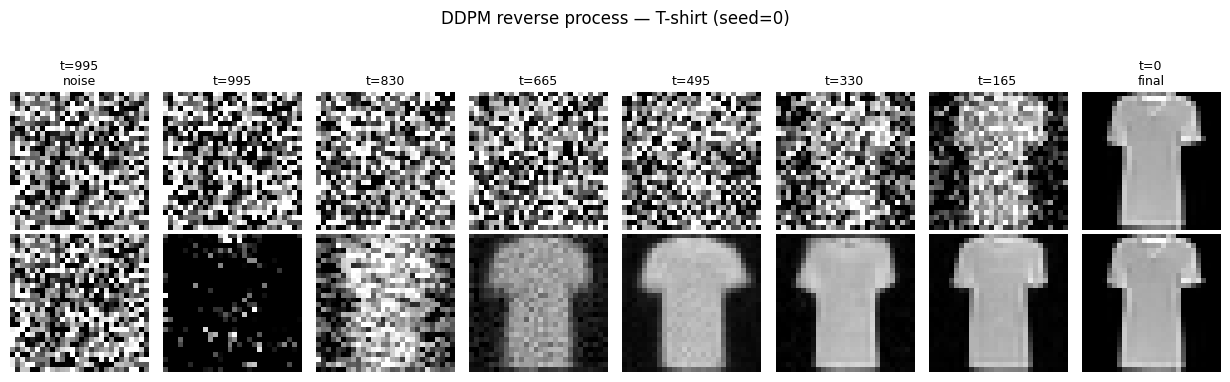

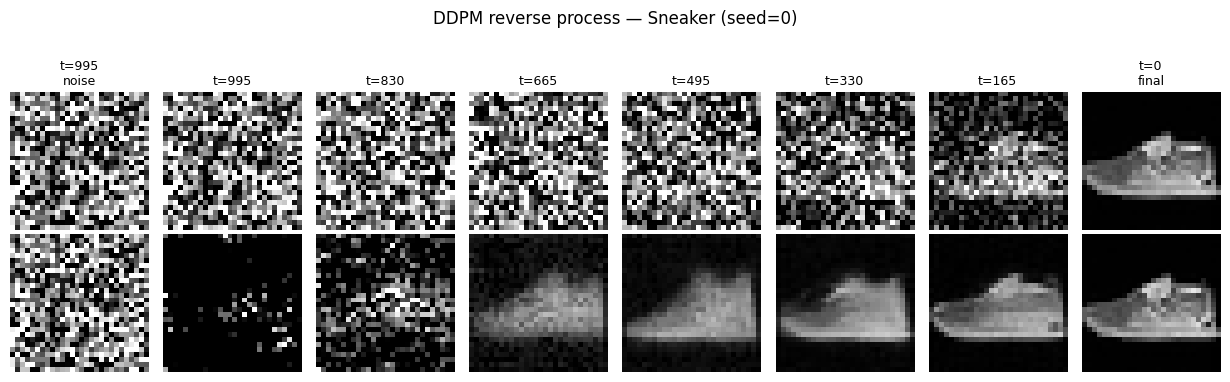

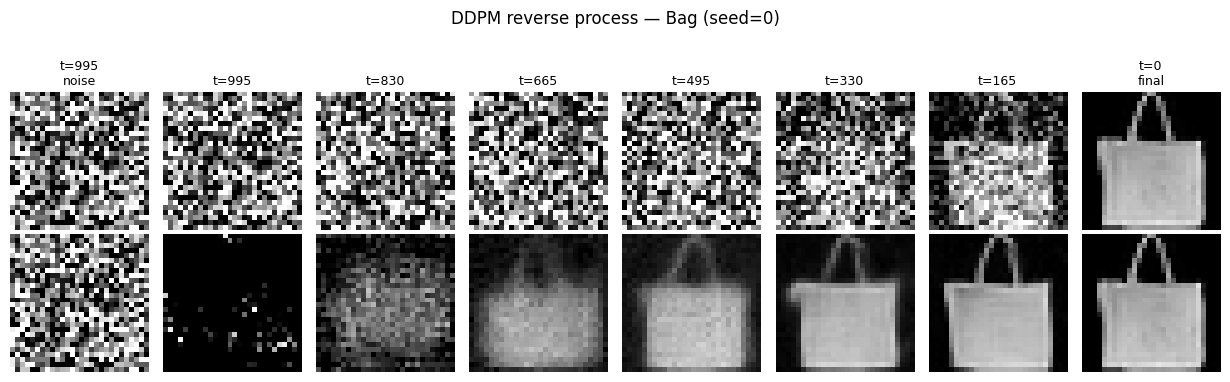

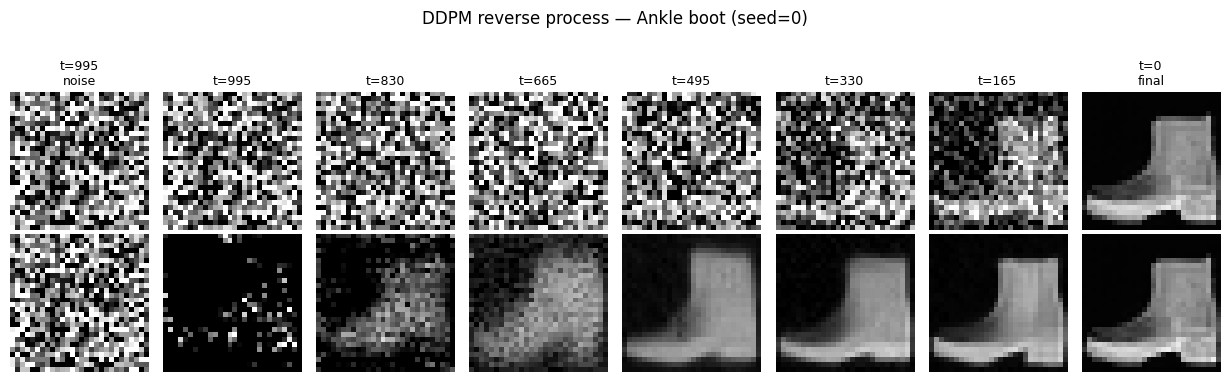

In [31]:
@torch.no_grad()
def ddpm_denoise_trajectory(
    class_idx, seed=0, steps=DDPM_INFERENCE_STEPS, n_checkpoints=N_CHECKPOINTS
):
    ddpm_unet.eval()
    ddpm_scheduler.set_timesteps(steps)
    timesteps = ddpm_scheduler.timesteps

    generator = torch.Generator(device=device).manual_seed(seed)
    sample = torch.randn(
        1, 1, IMAGE_SIZE, IMAGE_SIZE, generator=generator, device=device
    )
    label = torch.tensor([class_idx], device=device)

    capture_after = set(
        np.round(np.linspace(0, len(timesteps) - 1, n_checkpoints - 1)).astype(int)
    )

    xt_frames = [to_display_ddpm(sample)]
    x0_frames = [to_display_ddpm(sample)]
    titles = [f"t={int(timesteps[0])}\nnoise"]

    for i, t in enumerate(timesteps):
        noise_pred = ddpm_unet(sample, t, class_labels=label).sample
        out = ddpm_scheduler.step(noise_pred, t, sample)
        sample = out.prev_sample
        if i not in capture_after:
            continue
        xt_frames.append(to_display_ddpm(sample))
        pred_x0 = out.pred_original_sample
        x0_frames.append(
            to_display_ddpm(pred_x0 if pred_x0 is not None else sample)
        )
        titles.append(f"t={int(t)}" if i < len(timesteps) - 1 else f"t={int(t)}\nfinal")

    return xt_frames, x0_frames, titles


def show_ddpm_sample(class_idx, seed=0):
    xt, x0, titles = ddpm_denoise_trajectory(class_idx, seed=seed)
    show_trajectory_rows(
        [xt, x0],
        ["x_t", "pred x0"],
        titles,
        f"DDPM reverse process — {CLASS_NAMES[class_idx]} (seed={seed})",
    )


for class_idx in VIZ_CLASSES:
    show_ddpm_sample(class_idx, seed=0)

Several independent DDPM samples of the same class. Each row is one seed; columns are the same reverse-process checkpoints.

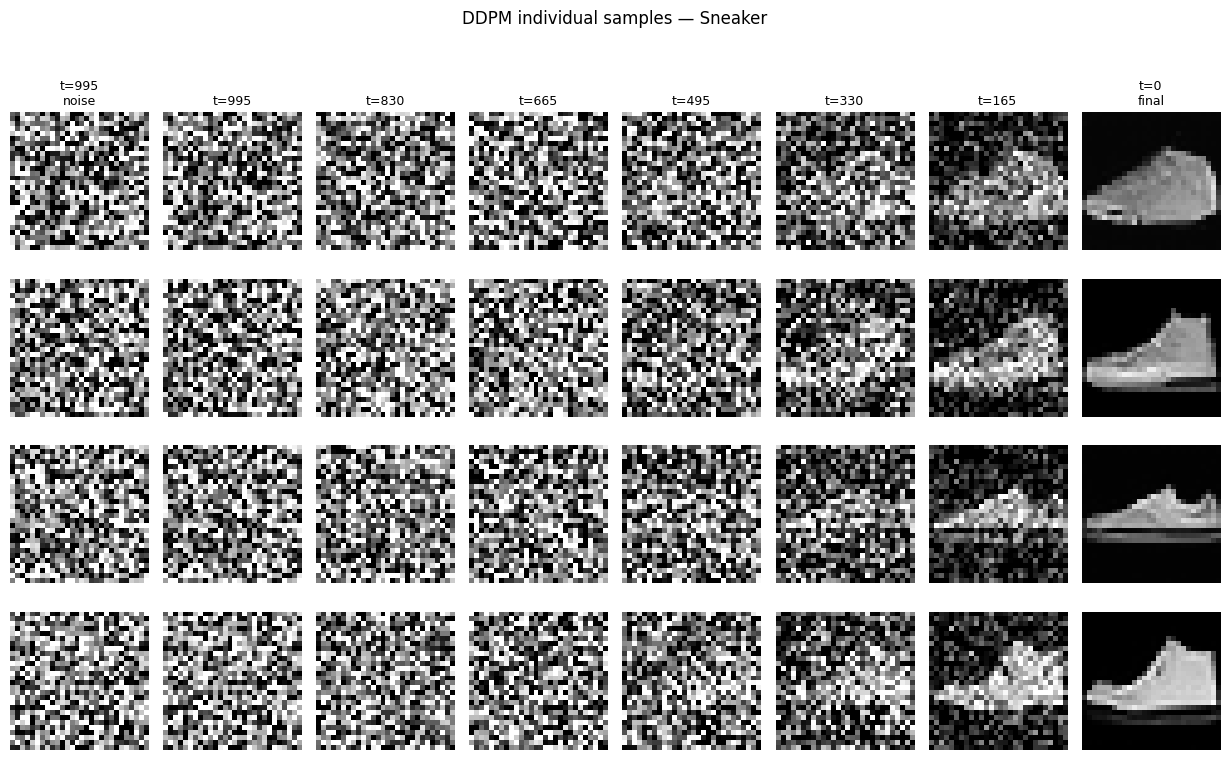

In [32]:
CLASS_IDX = 7
SEEDS = [0, 1, 2, 3]

xt_rows, titles = [], None
for seed in SEEDS:
    xt, _, titles = ddpm_denoise_trajectory(CLASS_IDX, seed=seed)
    xt_rows.append(xt)

show_trajectory_rows(
    xt_rows,
    [f"seed {s}" for s in SEEDS],
    titles,
    f"DDPM individual samples — {CLASS_NAMES[CLASS_IDX]}",
)

## Reverse process GIF

Every reverse-diffusion step for one sample, nearest-neighbor upscaled so the 28×28 pixels stay crisp. For each class we save a **full** GIF (all inference steps) and a **16-frame** subsample. Classes are shown side by side; frame counts are printed first, then the GIFs, then the save paths.

In [35]:
from IPython.display import HTML, display
from PIL import Image as PILImage


@torch.no_grad()
def ddpm_denoise_frames(class_idx, seed=0, steps=DDPM_INFERENCE_STEPS):
    ddpm_unet.eval()
    ddpm_scheduler.set_timesteps(steps)
    generator = torch.Generator(device=device).manual_seed(seed)
    sample = torch.randn(
        1, 1, IMAGE_SIZE, IMAGE_SIZE, generator=generator, device=device
    )
    label = torch.tensor([class_idx], device=device)
    frames = [to_display_ddpm(sample).numpy()]
    for t in ddpm_scheduler.timesteps:
        noise_pred = ddpm_unet(sample, t, class_labels=label).sample
        sample = ddpm_scheduler.step(noise_pred, t, sample).prev_sample
        frames.append(to_display_ddpm(sample).numpy())
    return frames


def subsample_frames(frames, n=16):
    idx = np.round(np.linspace(0, len(frames) - 1, n)).astype(int)
    return [frames[i] for i in idx]


def save_denoise_gif(frames, path, scale=8, duration_ms=40, hold_last=12):
    images = []
    for frame in frames:
        arr = (np.asarray(frame) * 255).clip(0, 255).astype(np.uint8)
        img = PILImage.fromarray(arr, mode="L")
        w, h = img.size
        img = img.resize((w * scale, h * scale), PILImage.NEAREST)
        images.append(img.convert("P"))
    images.extend([images[-1]] * hold_last)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    images[0].save(
        path,
        save_all=True,
        append_images=images[1:],
        duration=duration_ms,
        loop=0,
    )
    return path


def display_gifs_side_by_side(paths, labels, width=160):
    cells = []
    for path, label in zip(paths, labels):
        cells.append(
            "<td style='text-align:center; padding:8px;'>"
            f"<div style='font-size:12px; margin-bottom:4px;'>{label}</div>"
            f"<img src='{path}' width='{width}'/>"
            "</td>"
        )
    display(HTML("<table><tr>" + "".join(cells) + "</tr></table>"))


GIF_SEED = 0
N_SHORT_FRAMES = 32

results = []
for class_idx in VIZ_CLASSES:
    slug = CLASS_NAMES[class_idx].lower().replace(" ", "_")
    full_frames = ddpm_denoise_frames(class_idx, seed=GIF_SEED)
    short_frames = subsample_frames(full_frames, n=N_SHORT_FRAMES)
    full_path = f"./outputs/ddpm_denoise_{slug}.gif"
    short_path = f"./outputs/ddpm_denoise_{slug}_{N_SHORT_FRAMES}f.gif"
    save_denoise_gif(full_frames, full_path, duration_ms=40, hold_last=12)
    save_denoise_gif(short_frames, short_path, duration_ms=120, hold_last=4)
    results.append(
        {
            "name": CLASS_NAMES[class_idx],
            "full_path": full_path,
            "short_path": short_path,
            "n_full": len(full_frames),
            "n_short": len(short_frames),
        }
    )

print("frames")
for r in results:
    print(f"  {r['name']}: full={r['n_full']} | {N_SHORT_FRAMES}-frame={r['n_short']}")

print(f"\nfull reverse process ({results[0]['n_full']} frames)")
display_gifs_side_by_side(
    [r["full_path"] for r in results],
    [r["name"] for r in results],
)

print(f"\n{N_SHORT_FRAMES}-frame subsample")
display_gifs_side_by_side(
    [r["short_path"] for r in results],
    [r["name"] for r in results],
)

print("\nsaved")
for r in results:
    print(f"  {r['name']}: {r['full_path']}")
    print(f"           {r['short_path']}")


frames
  T-shirt: full=201 | 32-frame=32
  Sneaker: full=201 | 32-frame=32
  Bag: full=201 | 32-frame=32
  Ankle boot: full=201 | 32-frame=32

full reverse process (201 frames)


T-shirt,Sneaker,Bag,Ankle boot



32-frame subsample


T-shirt,Sneaker,Bag,Ankle boot



saved
  T-shirt: ./outputs/ddpm_denoise_t-shirt.gif
           ./outputs/ddpm_denoise_t-shirt_32f.gif
  Sneaker: ./outputs/ddpm_denoise_sneaker.gif
           ./outputs/ddpm_denoise_sneaker_32f.gif
  Bag: ./outputs/ddpm_denoise_bag.gif
           ./outputs/ddpm_denoise_bag_32f.gif
  Ankle boot: ./outputs/ddpm_denoise_ankle_boot.gif
           ./outputs/ddpm_denoise_ankle_boot_32f.gif


## Side-by-side individual samples

Final generated images only — one sample per column. CVAE has no intermediate states, so this is the only CVAE view.

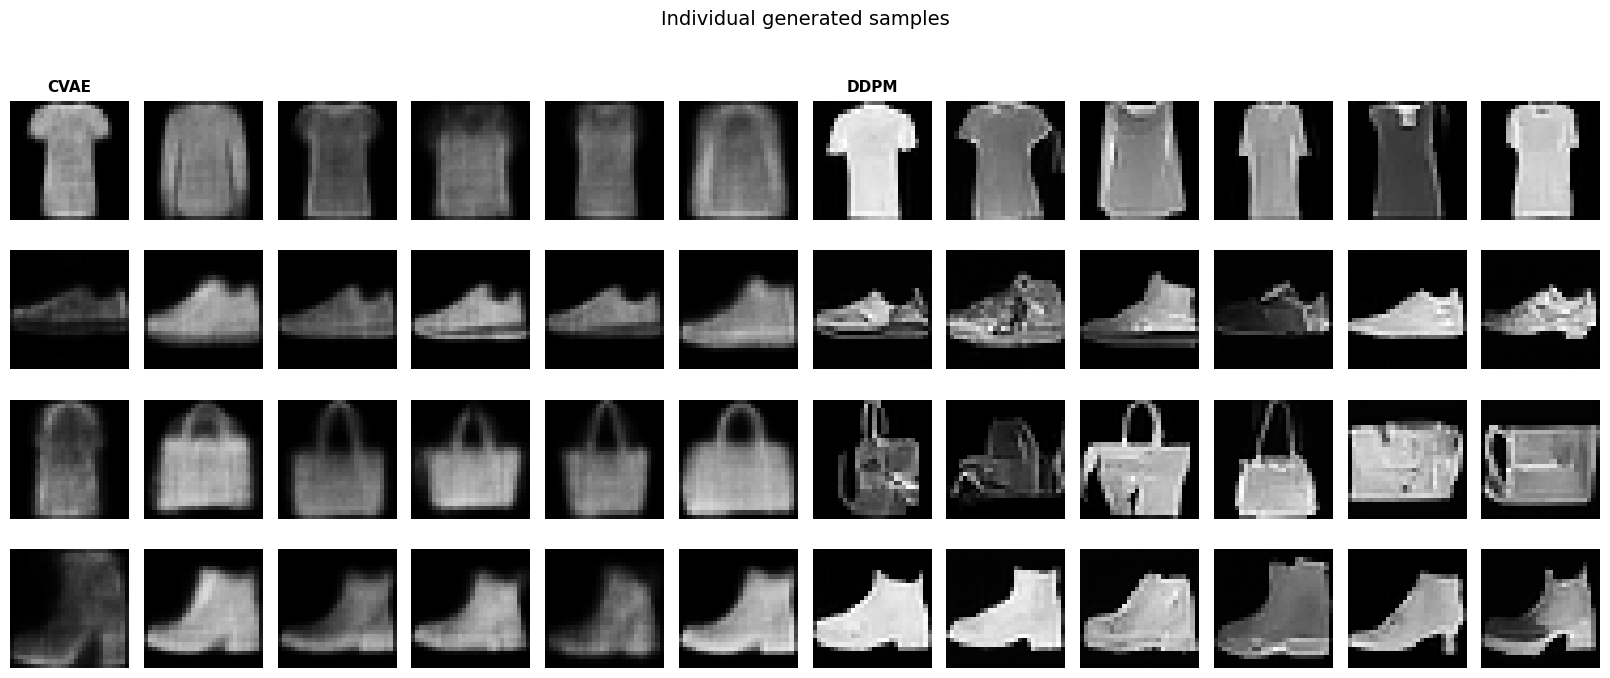

In [34]:
@torch.no_grad()
def generate_cvae(class_idx, n, seed):
    generator = torch.Generator(device=device).manual_seed(seed)
    z = torch.randn(n, LATENT_DIM, generator=generator, device=device)
    y = labels_to_onehot(torch.full((n,), class_idx, device=device))
    return to_display_cvae(cvae.decode(z, y))


@torch.no_grad()
def generate_ddpm(class_idx, n, seed, steps=DDPM_INFERENCE_STEPS):
    ddpm_unet.eval()
    ddpm_scheduler.set_timesteps(steps)
    generator = torch.Generator(device=device).manual_seed(seed)
    samples = torch.randn(
        n, 1, IMAGE_SIZE, IMAGE_SIZE, generator=generator, device=device
    )
    labels = torch.full((n,), class_idx, dtype=torch.long, device=device)
    for t in ddpm_scheduler.timesteps:
        noise_pred = ddpm_unet(samples, t, class_labels=labels).sample
        samples = ddpm_scheduler.step(noise_pred, t, samples).prev_sample
    return to_display_ddpm(samples)


N_SHOW = 6
n_rows = len(VIZ_CLASSES)
fig, axes = plt.subplots(n_rows, N_SHOW * 2, figsize=(1.35 * N_SHOW * 2, 1.7 * n_rows))

for r, class_idx in enumerate(VIZ_CLASSES):
    cvae_imgs = generate_cvae(class_idx, N_SHOW, seed=0)
    ddpm_imgs = generate_ddpm(class_idx, N_SHOW, seed=0)
    for i in range(N_SHOW):
        ax_c = axes[r, i]
        ax_d = axes[r, N_SHOW + i]
        ax_c.imshow(cvae_imgs[i], cmap="gray", vmin=0, vmax=1)
        ax_d.imshow(ddpm_imgs[i], cmap="gray", vmin=0, vmax=1)
        ax_c.axis("off")
        ax_d.axis("off")
        if r == 0:
            if i == 0:
                ax_c.set_title("CVAE", fontsize=11, fontweight="bold")
            if i == 0:
                ax_d.set_title("DDPM", fontsize=11, fontweight="bold")
    axes[r, 0].set_ylabel(
        CLASS_NAMES[class_idx], fontsize=10, rotation=0, labelpad=40, va="center"
    )

fig.suptitle("Individual generated samples", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()